# Step 10 – Adoption & Origination Regression

**RQ2 (part 1)**: *Which city characteristics are associated with innovation-oriented roles and faster adoption within the ecosystem of prominent open-AI projects?*

### Modelling strategy

Due to the binary nature of the adoption lag variable (0 = originator, 1 = non-originator), we adapt the analysis into three complementary models:

| Model | Level | DV | Method | n |
|---|---|---|---|---|
| A | City–Project | `is_originator` (0/1) | Logistic regression (clustered SE) | 27,806 |
| B | City | `originator_share` | OLS regression | 104 |
| C | City | `log(adoption_count)` | OLS regression | 104 |

This allows us to answer:
- **Model A**: What city characteristics predict whether a city is the *originator* of a project it participates in?
- **Model B**: What explains variation in cities' overall origination intensity?
- **Model C**: What drives the breadth of project adoption across cities?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120})

DATA = Path('..') / 'data' / 'output'
city_attr = pd.read_csv(DATA / 'city_attributes.csv')
adoption  = pd.read_csv(DATA / 'city_project_adoption_events.csv')

print(f'city_attributes: {city_attr.shape}')
print(f'adoption_events: {adoption.shape}')

city_attributes: (150, 28)
adoption_events: (27806, 6)


## 10.1 – Prepare Variables

In [2]:
# ---------- City-level dataset ----------
df_city = city_attr[city_attr['adoption_count'] > 0].copy()  # 104 active cities

# Dependent variables
df_city['originator_share'] = df_city['origination_count'] / df_city['adoption_count']
df_city['log_adoption'] = np.log1p(df_city['adoption_count'])

# Independent variables (log-transform skewed ones)
df_city['log_degree'] = np.log1p(df_city['weighted_degree'])
df_city['log_population'] = np.log1p(df_city['population_million'])
df_city['log_gdp'] = np.log(df_city['gdp_per_capita'])
df_city['log_entity'] = np.log1p(df_city['entity_count'])

print(f'City-level observations: {len(df_city)}')
print(f'\noriginator_share: mean={df_city["originator_share"].mean():.4f}, '
      f'std={df_city["originator_share"].std():.4f}')
print(f'log_adoption:     mean={df_city["log_adoption"].mean():.2f}, '
      f'std={df_city["log_adoption"].std():.2f}')

City-level observations: 104

originator_share: mean=0.0934, std=0.0725
log_adoption:     mean=5.12, std=0.94


In [3]:
# ---------- City-Project level dataset ----------
# Merge city features onto adoption events
merge_cols = ['city', 'log_degree', 'log_population', 'log_gdp', 'log_entity',
              'education_tertiary_pct', 'internet_users_pct',
              'rd_expenditure_pct', 'research_capacity',
              'betweenness', 'region']

df_cp = adoption.merge(df_city[merge_cols], on='city', how='inner')
print(f'City-Project observations: {len(df_cp)}')
print(f'is_originator: {df_cp["is_originator"].value_counts().to_dict()}')

City-Project observations: 28127
is_originator: {0: 25182, 1: 2945}


## 10.2 – Model A: City–Project Logistic Regression

DV: `is_originator` (binary)  
Unit: city × project pair (n ≈ 27,800)  
Clustered standard errors at city level to account for within-city correlation.

In [4]:
# Standardise IVs for comparable coefficients
iv_cols = ['log_degree', 'log_population', 'log_gdp',
           'education_tertiary_pct', 'internet_users_pct',
           'rd_expenditure_pct', 'research_capacity',
           'betweenness', 'log_entity']

scaler = StandardScaler()
for col in iv_cols:
    df_cp[col + '_z'] = scaler.fit_transform(df_cp[[col]])

iv_z = [c + '_z' for c in iv_cols]

# Logistic regression with clustered SE
formula_a = f'is_originator ~ {" + ".join(iv_z)}'
model_a = smf.logit(formula_a, data=df_cp).fit(
    cov_type='cluster', cov_kwds={'groups': df_cp['city']},
    disp=False, maxiter=200
)

print('Model A: Logistic Regression – P(is_originator = 1)')
print(f'Observations: {model_a.nobs:.0f}')
print(f'Pseudo R²: {model_a.prsquared:.4f}')
print(f'Log-Likelihood: {model_a.llf:.1f}')
print()
print(model_a.summary2().tables[1].to_string())

Model A: Logistic Regression – P(is_originator = 1)
Observations: 28127
Pseudo R²: 0.0353
Log-Likelihood: -9098.3

                             Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
Intercept                -2.250265  0.055443 -40.587179  0.000000e+00 -2.358931 -2.141599
log_degree_z             -0.532331  0.091169  -5.838929  5.253754e-09 -0.711020 -0.353643
log_population_z         -0.339307  0.142674  -2.378196  1.739758e-02 -0.618943 -0.059671
log_gdp_z                 0.039318  0.119603   0.328740  7.423520e-01 -0.195099  0.273735
education_tertiary_pct_z  0.121663  0.061195   1.988118  4.679864e-02  0.001723  0.241603
internet_users_pct_z     -0.219316  0.132400  -1.656459  9.762893e-02 -0.478816  0.040184
rd_expenditure_pct_z      0.003524  0.086628   0.040681  9.675504e-01 -0.166263  0.173311
research_capacity_z       0.011771  0.085432   0.137779  8.904150e-01 -0.155674  0.179215
betweenness_z            -0.016015  0.017646  -0.907577  3.641018e-01 -0.05

In [5]:
# Odds ratios
odds = np.exp(model_a.params)
ci = np.exp(model_a.conf_int())
ci.columns = ['OR_lower', 'OR_upper']
odds_df = pd.DataFrame({
    'Odds Ratio': odds,
    'OR_lower': ci['OR_lower'],
    'OR_upper': ci['OR_upper'],
    'p-value': model_a.pvalues,
    'sig': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' 
            for p in model_a.pvalues]
}).round(4)

print('Odds Ratios (Model A):')
display(odds_df)

Odds Ratios (Model A):


,Odds Ratio,OR_lower,OR_upper,p-value,sig
Intercept,0.1054,0.0945,0.1175,0.0000,***
log_degree_z,0.5872,0.4911,0.7021,0.0000,***
log_population_z,0.7123,0.5385,0.9421,0.0174,*
log_gdp_z,1.0401,0.8228,1.3149,0.7424,
education_tertiary_pct_z,1.1294,1.0017,1.2733,0.0468,*
internet_users_pct_z,0.8031,0.6195,1.0410,0.0976,
rd_expenditure_pct_z,1.0035,0.8468,1.1892,0.9676,
research_capacity_z,1.0118,0.8558,1.1963,0.8904,
betweenness_z,0.9841,0.9507,1.0187,0.3641,
log_entity_z,2.3482,1.9574,2.8171,0.0000,***


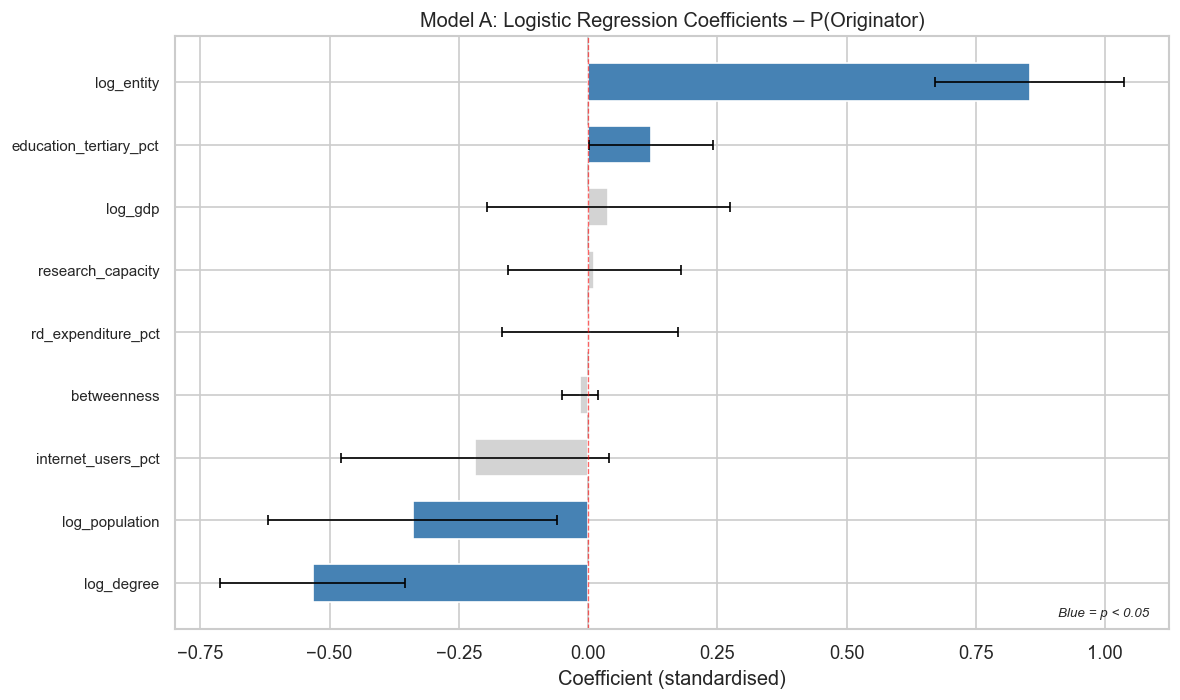

In [6]:
# Coefficient plot for Model A
coef_df = pd.DataFrame({
    'variable': iv_cols,
    'coef': model_a.params[1:].values,  # exclude intercept
    'se': model_a.bse[1:].values,
    'pval': model_a.pvalues[1:].values,
})
coef_df['ci_lower'] = coef_df['coef'] - 1.96 * coef_df['se']
coef_df['ci_upper'] = coef_df['coef'] + 1.96 * coef_df['se']
coef_df['significant'] = coef_df['pval'] < 0.05
coef_df = coef_df.sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if s else 'lightgrey' for s in coef_df['significant']]
ax.barh(range(len(coef_df)), coef_df['coef'], color=colors, edgecolor='white', height=0.6)
ax.errorbar(coef_df['coef'], range(len(coef_df)),
            xerr=1.96 * coef_df['se'], fmt='none', color='black', capsize=3, lw=1)
ax.axvline(0, color='red', ls='--', lw=0.8, alpha=0.6)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['variable'], fontsize=9)
ax.set_xlabel('Coefficient (standardised)')
ax.set_title('Model A: Logistic Regression Coefficients – P(Originator)',
             fontsize=12)
ax.text(0.98, 0.02, 'Blue = p < 0.05', transform=ax.transAxes,
        ha='right', fontsize=8, style='italic')
plt.tight_layout()
plt.show()

## 10.3 – Model B: City-Level OLS – Originator Share

In [7]:
# Standardise IVs at city level
for col in iv_cols:
    df_city[col + '_z'] = StandardScaler().fit_transform(df_city[[col]])

formula_b = f'originator_share ~ {" + ".join(iv_z)}'
model_b = smf.ols(formula_b, data=df_city).fit(
    cov_type='HC1'  # robust SE
)

print('Model B: OLS – Originator Share')
print(f'Observations: {model_b.nobs:.0f}')
print(f'R²: {model_b.rsquared:.4f}')
print(f'Adj R²: {model_b.rsquared_adj:.4f}')
print(f'F-stat p-value: {model_b.f_pvalue:.4e}')
print()
print(model_b.summary2().tables[1].to_string())

Model B: OLS – Originator Share
Observations: 104
R²: 0.3587
Adj R²: 0.2973
F-stat p-value: 1.3564e-16

                             Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
Intercept                 0.093357  0.005962  15.658132  2.923576e-55  0.081671  0.105043
log_degree_z             -0.042911  0.011555  -3.713499  2.044135e-04 -0.065559 -0.020263
log_population_z         -0.026883  0.014223  -1.890076  5.874778e-02 -0.054760  0.000994
log_gdp_z                -0.009663  0.012561  -0.769310  4.417090e-01 -0.034282  0.014956
education_tertiary_pct_z  0.005944  0.004578   1.298134  1.942413e-01 -0.003030  0.014917
internet_users_pct_z     -0.009122  0.007263  -1.256008  2.091132e-01 -0.023357  0.005113
rd_expenditure_pct_z      0.004324  0.006924   0.624508  5.322940e-01 -0.009246  0.017894
research_capacity_z      -0.006788  0.011000  -0.617049  5.372022e-01 -0.028348  0.014773
betweenness_z             0.004225  0.005322   0.793858  4.272781e-01 -0.006206  0.014

## 10.4 – Model C: City-Level OLS – Adoption Breadth

In [8]:
formula_c = f'log_adoption ~ {" + ".join(iv_z)}'
model_c = smf.ols(formula_c, data=df_city).fit(
    cov_type='HC1'
)

print('Model C: OLS – log(Adoption Count)')
print(f'Observations: {model_c.nobs:.0f}')
print(f'R²: {model_c.rsquared:.4f}')
print(f'Adj R²: {model_c.rsquared_adj:.4f}')
print(f'F-stat p-value: {model_c.f_pvalue:.4e}')
print()
print(model_c.summary2().tables[1].to_string())

Model C: OLS – log(Adoption Count)
Observations: 104
R²: 0.9817
Adj R²: 0.9799
F-stat p-value: 3.5655e-88

                             Coef.  Std.Err.           z          P>|z|    [0.025    0.975]
Intercept                 5.120758  0.013063  391.992734   0.000000e+00  5.095154  5.146362
log_degree_z              0.758748  0.033686   22.524027  2.414020e-112  0.692724  0.824771
log_population_z          0.003832  0.026960    0.142123   8.869828e-01 -0.049009  0.056672
log_gdp_z                 0.013207  0.038622    0.341942   7.323943e-01 -0.062492  0.088905
education_tertiary_pct_z -0.018061  0.013764   -1.312161   1.894659e-01 -0.045038  0.008916
internet_users_pct_z     -0.048899  0.034264   -1.427127   1.535433e-01 -0.116056  0.018257
rd_expenditure_pct_z      0.040513  0.019537    2.073645   3.811232e-02  0.002221  0.078804
research_capacity_z       0.008943  0.019364    0.461836   6.441989e-01 -0.029010  0.046896
betweenness_z             0.057724  0.009929    5.813536   6.1166

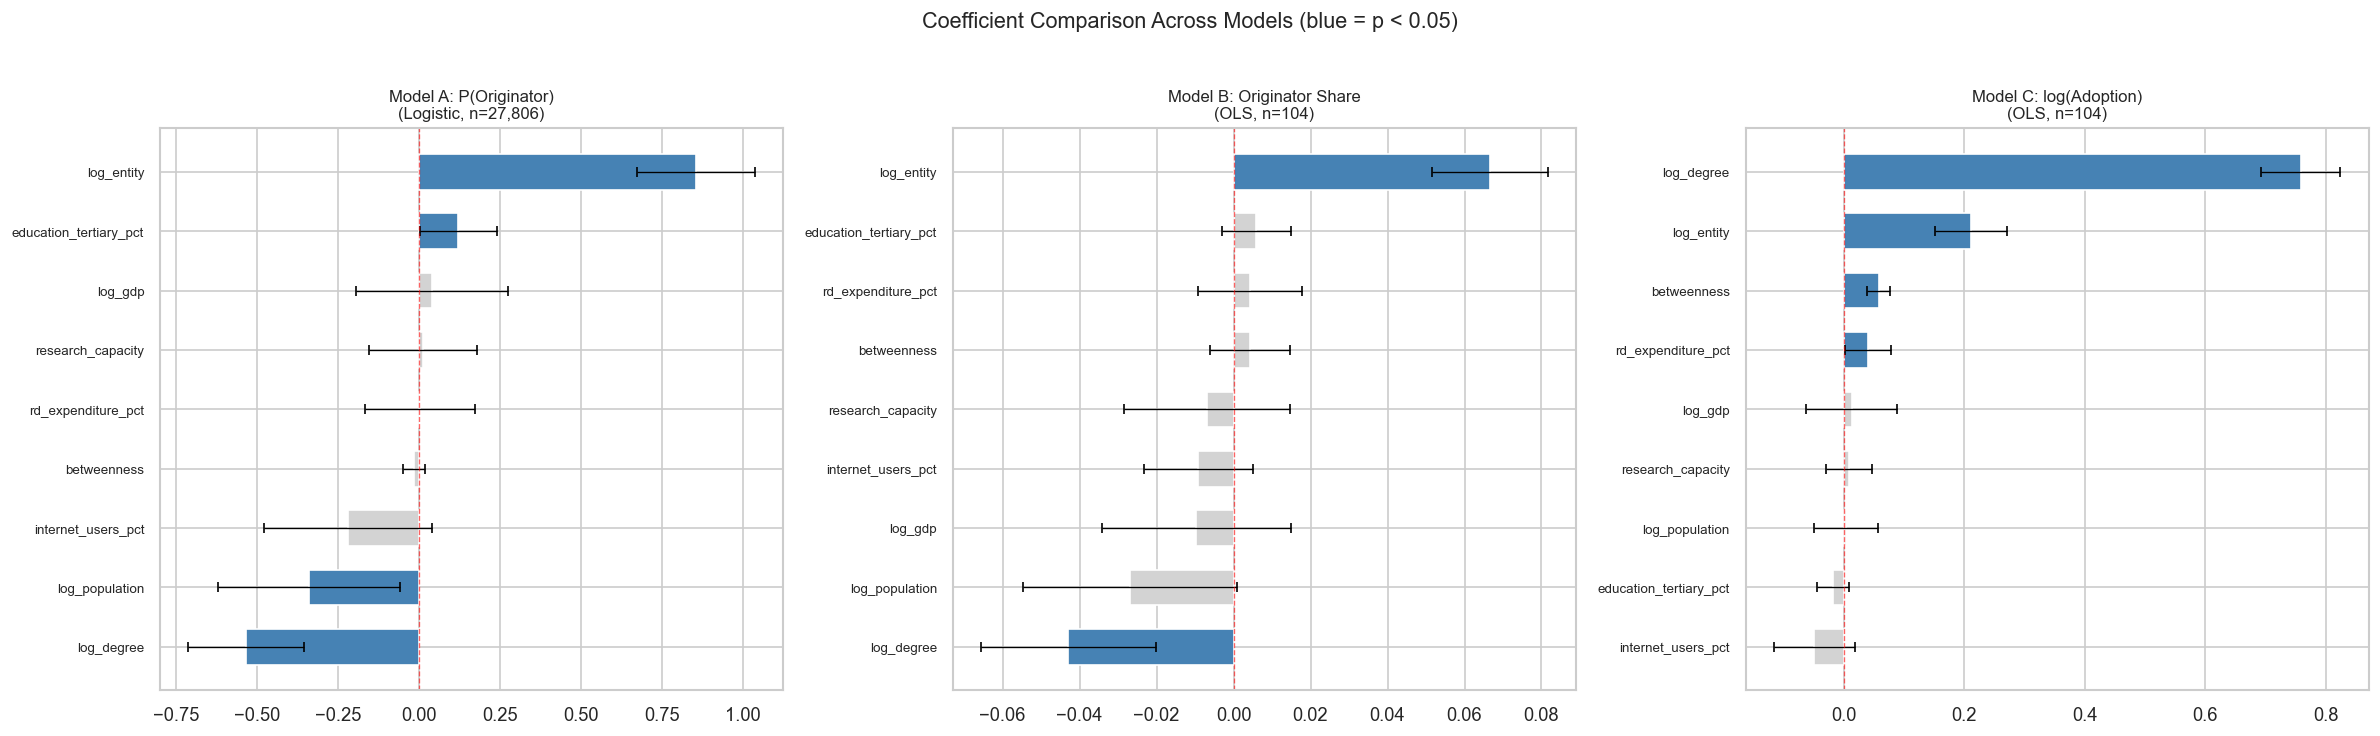

In [9]:
# Coefficient comparison across all three models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model, title) in zip(axes, [
    (model_a, 'Model A: P(Originator)\n(Logistic, n=27,806)'),
    (model_b, 'Model B: Originator Share\n(OLS, n=104)'),
    (model_c, 'Model C: log(Adoption)\n(OLS, n=104)'),
]):
    params = model.params[1:]  # exclude intercept
    se = model.bse[1:]
    pvals = model.pvalues[1:]

    sorted_idx = params.argsort()
    names = [iv_cols[i] for i in sorted_idx]
    vals = params.values[sorted_idx]
    errs = se.values[sorted_idx]
    sigs = pvals.values[sorted_idx] < 0.05

    colors = ['steelblue' if s else 'lightgrey' for s in sigs]
    ax.barh(range(len(names)), vals, color=colors, edgecolor='white', height=0.6)
    ax.errorbar(vals, range(len(names)),
                xerr=1.96 * errs, fmt='none', color='black', capsize=3, lw=0.8)
    ax.axvline(0, color='red', ls='--', lw=0.8, alpha=0.6)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(title, fontsize=10)

plt.suptitle('Coefficient Comparison Across Models (blue = p < 0.05)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10.5 – Diagnostics

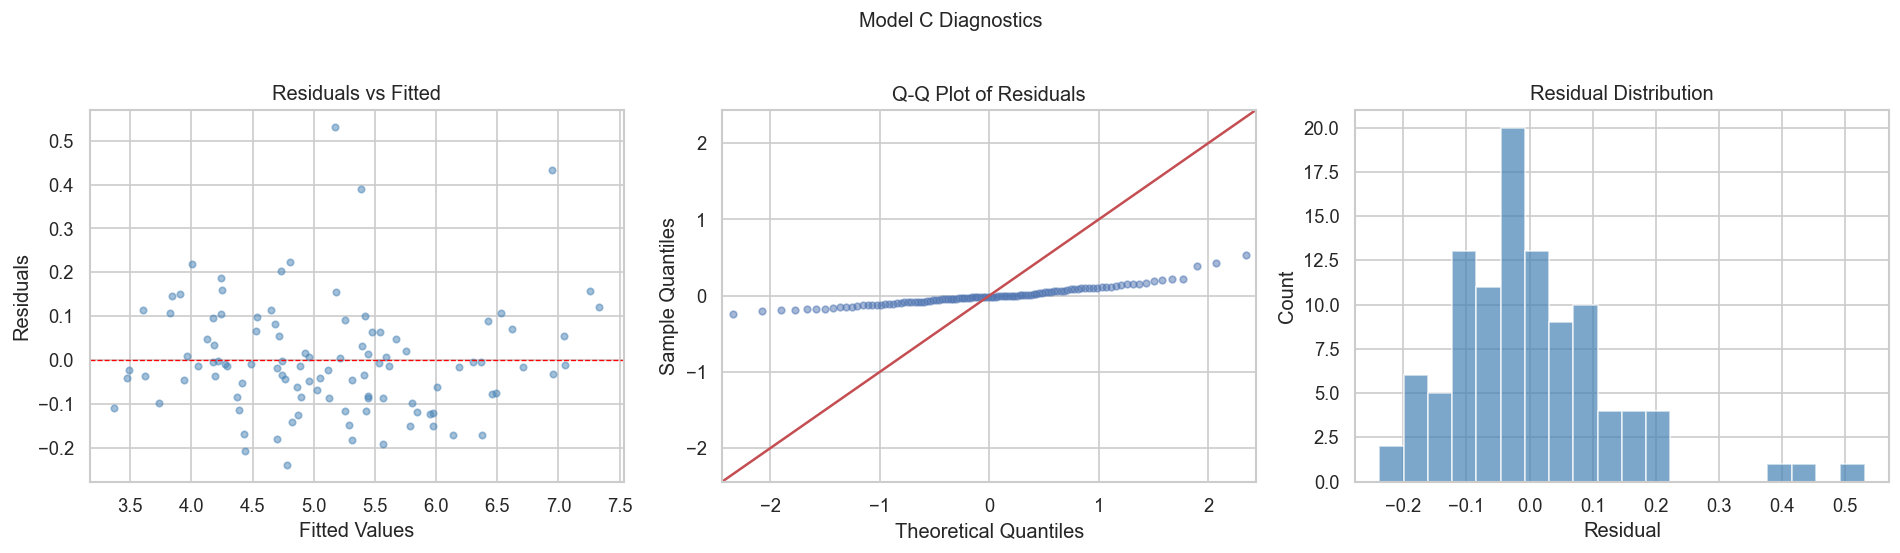

Variance Inflation Factors:


,Variable,VIF
2,log_gdp,10.84
4,internet_users_pct,6.00
0,log_degree,4.73
8,log_entity,3.53
5,rd_expenditure_pct,2.47
1,log_population,2.27
3,education_tertiary_pct,2.15
6,research_capacity,1.90
7,betweenness,1.73



⚠️  Variables with VIF > 10 (potential multicollinearity):
Variable       VIF
 log_gdp 10.835335


In [10]:
# Residual diagnostics for Model C (OLS)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Residuals vs fitted
resid = model_c.resid
fitted = model_c.fittedvalues
axes[0].scatter(fitted, resid, s=15, alpha=0.5, color='steelblue')
axes[0].axhline(0, color='red', ls='--', lw=0.8)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot
sm.qqplot(resid, line='45', ax=axes[1], markersize=4, alpha=0.5)
axes[1].set_title('Q-Q Plot of Residuals')

# Residual histogram
axes[2].hist(resid, bins=20, edgecolor='white', color='steelblue', alpha=0.7)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.suptitle('Model C Diagnostics', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# VIF check
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_city[iv_z].dropna()
X_vif_const = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    'Variable': iv_cols,
    'VIF': [variance_inflation_factor(X_vif_const.values, i+1)
            for i in range(len(iv_cols))]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factors:')
display(vif_data.round(2))

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print('\n⚠️  Variables with VIF > 10 (potential multicollinearity):')
    print(high_vif.to_string(index=False))
else:
    print('\n✓ No severe multicollinearity (all VIF < 10)')

## 10.6 – Summary of Findings

In [11]:
# Consolidated results table
results = pd.DataFrame({
    'Variable': iv_cols,
    'A: Logit coef': model_a.params[1:].values.round(4),
    'A: p-val': model_a.pvalues[1:].values.round(4),
    'B: OLS coef': model_b.params[1:].values.round(4),
    'B: p-val': model_b.pvalues[1:].values.round(4),
    'C: OLS coef': model_c.params[1:].values.round(4),
    'C: p-val': model_c.pvalues[1:].values.round(4),
})

def _sig(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    if p < 0.1: return '.'
    return ''

for m in ['A', 'B', 'C']:
    results[f'{m}: sig'] = results[f'{m}: p-val'].apply(_sig)

print('=' * 80)
print('CONSOLIDATED REGRESSION RESULTS')
print('=' * 80)
display(results)

print(f'\nModel A – Pseudo R² = {model_a.prsquared:.4f}')
print(f'Model B – R² = {model_b.rsquared:.4f}, Adj R² = {model_b.rsquared_adj:.4f}')
print(f'Model C – R² = {model_c.rsquared:.4f}, Adj R² = {model_c.rsquared_adj:.4f}')

print('''
Key interpretations:
- Model A reveals which city characteristics raise the odds of being a project
  originator rather than a non-originating adopter.
- Model B identifies what drives a higher share of origination among adopted
  projects — i.e., innovation intensity.
- Model C explains what determines the breadth of project adoption — i.e.,
  how many prominent projects a city participates in.
- Significant positive coefficients in Model A/B point to factors enabling
  innovation-oriented roles; significant positive coefficients in Model C
  point to factors enabling faster and broader adoption.
''')

CONSOLIDATED REGRESSION RESULTS


,Variable,A: Logit coef,A: p-val,B: OLS coef,B: p-val,C: OLS coef,C: p-val,A: sig,B: sig,C: sig
0,log_degree,-0.5323,0.0000,-0.0429,0.0002,0.7587,0.0000,***,***,***
1,log_population,-0.3393,0.0174,-0.0269,0.0587,0.0038,0.8870,*,.,
2,log_gdp,0.0393,0.7424,-0.0097,0.4417,0.0132,0.7324,,,
3,education_tertiary_pct,0.1217,0.0468,0.0059,0.1942,-0.0181,0.1895,*,,
4,internet_users_pct,-0.2193,0.0976,-0.0091,0.2091,-0.0489,0.1535,.,,
5,rd_expenditure_pct,0.0035,0.9676,0.0043,0.5323,0.0405,0.0381,,,*
6,research_capacity,0.0118,0.8904,-0.0068,0.5372,0.0089,0.6442,,,
7,betweenness,-0.0160,0.3641,0.0042,0.4273,0.0577,0.0000,,,***
8,log_entity,0.8537,0.0000,0.0665,0.0000,0.2110,0.0000,***,***,***



Model A – Pseudo R² = 0.0353
Model B – R² = 0.3587, Adj R² = 0.2973
Model C – R² = 0.9817, Adj R² = 0.9799

Key interpretations:
- Model A reveals which city characteristics raise the odds of being a project
  originator rather than a non-originating adopter.
- Model B identifies what drives a higher share of origination among adopted
  projects — i.e., innovation intensity.
- Model C explains what determines the breadth of project adoption — i.e.,
  how many prominent projects a city participates in.
- Significant positive coefficients in Model A/B point to factors enabling
  innovation-oriented roles; significant positive coefficients in Model C
  point to factors enabling faster and broader adoption.

